# Análise de Preços - Supermercados RJ

Análise de dados de preços coletados automaticamente dos supermercados **Zona Sul** e **Guanabara** no Rio de Janeiro.

Dados coletados via scripts Python que rodam diariamente no GitHub Actions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import glob
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Carregamento dos Dados

In [2]:
# Carregar dados Guanabara
guanabara = pd.read_csv('guanabara.txt', sep=';', encoding='latin-1')
guanabara['preco'] = guanabara['preco'].str.replace(',', '.').astype(float)
guanabara['data'] = pd.to_datetime(guanabara['data'])
guanabara['supermercado'] = 'Guanabara'
print(f'Guanabara: {len(guanabara):,} registros')
print(f'Período: {guanabara["data"].min().date()} a {guanabara["data"].max().date()}')
print(f'Produtos únicos: {guanabara["produto"].nunique():,}')

Guanabara: 107,758 registros
Período: 2024-09-13 a 2026-05-20
Produtos únicos: 607


In [3]:
# Carregar dados Zona Sul (arquivos mensais)
zsul_files = sorted(glob.glob('zsul_*.txt'))
zsul_list = []
for f in zsul_files:
    df = pd.read_csv(f, sep=';', encoding='latin-1')
    zsul_list.append(df)
    print(f'{f}: {len(df):,} registros')

zsul = pd.concat(zsul_list, ignore_index=True)
zsul['preco'] = pd.to_numeric(zsul['preco'], errors='coerce')
zsul['data'] = pd.to_datetime(zsul['data'])
zsul['supermercado'] = 'Zona Sul'
print(f'\nZona Sul total: {len(zsul):,} registros')
print(f'Período: {zsul["data"].min().date()} a {zsul["data"].max().date()}')
print(f'Produtos únicos: {zsul["produto"].nunique():,}')

zsul_202601.txt: 667 registros
zsul_202602.txt: 1,354 registros
zsul_202603.txt: 1,446 registros
zsul_202604.txt: 1,443 registros
zsul_202605.txt: 1,008 registros

Zona Sul total: 5,918 registros
Período: 2026-01-24 a 2026-05-21
Produtos únicos: 174


## 2. Visão Geral dos Dados

In [4]:
# Resumo por supermercado
resumo = []
for nome, df in [('Guanabara', guanabara), ('Zona Sul', zsul)]:
    resumo.append({
        'Supermercado': nome,
        'Registros': f'{len(df):,}',
        'Produtos Únicos': f'{df["produto"].nunique():,}',
        'Preço Médio': f'R$ {df["preco"].mean():.2f}',
        'Preço Mediana': f'R$ {df["preco"].median():.2f}',
        'Preço Mínimo': f'R$ {df["preco"].min():.2f}',
        'Preço Máximo': f'R$ {df["preco"].max():.2f}',
    })

pd.DataFrame(resumo)

,Supermercado,Registros,Produtos Únicos,Preço Médio,Preço Mediana,Preço Mínimo,Preço Máximo
0,Guanabara,"107,758",607,R$ 17.44,R$ 11.98,R$ 0.69,R$ 202.95
1,Zona Sul,"5,918",174,R$ 13.51,R$ 7.99,R$ 0.75,R$ 250.00


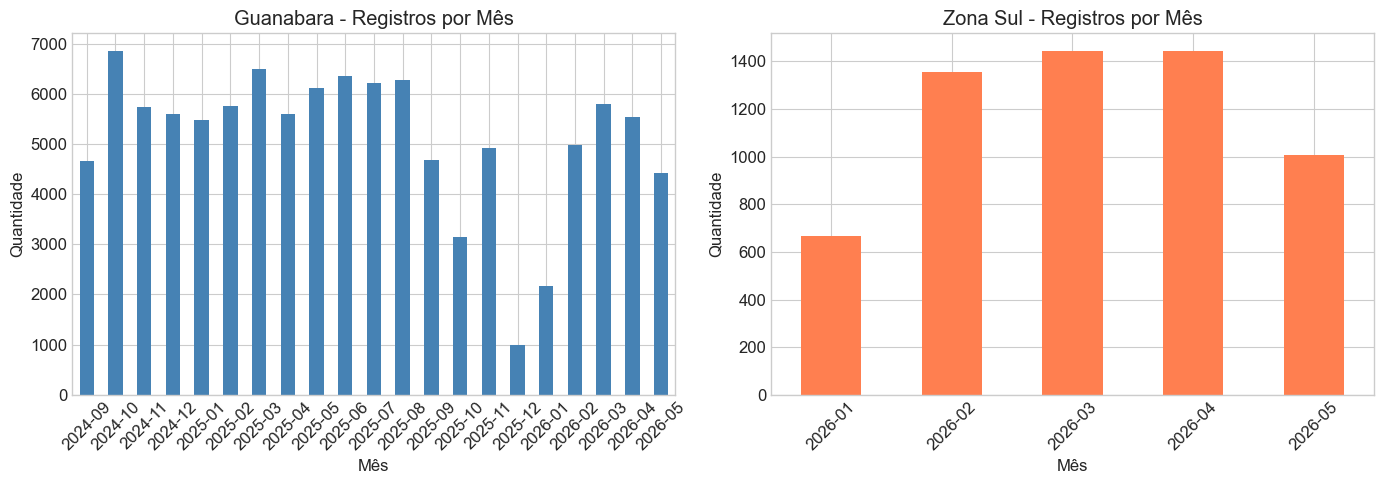

In [5]:
# Evolução do volume de coleta por mês
guanabara['mes'] = guanabara['data'].dt.to_period('M')
zsul['mes'] = zsul['data'].dt.to_period('M')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

guanabara.groupby('mes').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Guanabara - Registros por Mês')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

zsul.groupby('mes').size().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Zona Sul - Registros por Mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Quantidade')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Análise por Setor/Categoria

In [6]:
# Guanabara - setores
setores_guan = guanabara.groupby('setor').agg(
    qtd=('produto', 'count'),
    produtos_unicos=('produto', 'nunique'),
    preco_medio=('preco', 'mean'),
    preco_mediana=('preco', 'median')
).sort_values('qtd', ascending=False)

print('=== Guanabara - Setores ===')
setores_guan.style.format({'preco_medio': 'R$ {:.2f}', 'preco_mediana': 'R$ {:.2f}'})

=== Guanabara - Setores ===


,qtd,produtos_unicos,preco_medio,preco_mediana
setor,,,,
HIGIÃNE PESSOAL,30969,145,R$ 15.16,R$ 13.90
BEBIDA,14670,79,R$ 29.06,R$ 5.79
LIMPEZA,11002,84,R$ 11.36,R$ 8.98
CANTINHO DO BEBÃ,9605,49,R$ 13.88,R$ 11.99
FRIOS E LATICÃNIOS,7876,39,R$ 28.58,R$ 21.90
CONSERVAS,7828,50,R$ 9.84,R$ 5.99
MATINAIS E PADARIA,6342,32,R$ 10.94,R$ 5.99
AÃOUGUE,5733,46,R$ 23.99,R$ 17.98
CEREAIS E FARINACEOS,4760,23,R$ 13.73,R$ 7.57


In [7]:
# Zona Sul - marcas
marcas_zsul = zsul.groupby('marca').agg(
    qtd=('produto', 'count'),
    produtos_unicos=('produto', 'nunique'),
    preco_medio=('preco', 'mean'),
    preco_mediana=('preco', 'median')
).sort_values('qtd', ascending=False).head(20)

print('=== Zona Sul - Top 20 Marcas ===')
marcas_zsul.style.format({'preco_medio': 'R$ {:.2f}', 'preco_mediana': 'R$ {:.2f}'})

=== Zona Sul - Top 20 Marcas ===


,qtd,produtos_unicos,preco_medio,preco_mediana
marca,,,,
Zona Sul,1905,45,R$ 13.76,R$ 5.84
CARIORTA,509,10,R$ 20.63,R$ 11.99
COCA COLA,207,4,R$ 8.15,R$ 5.69
HAPPY EGGS,188,2,R$ 19.15,R$ 24.99
GRANDE HOTEL,173,2,R$ 10.80,R$ 12.99
NEVE,158,3,R$ 28.65,R$ 31.99
NESTLE,157,3,R$ 5.79,R$ 4.89
LEAO,143,2,R$ 7.89,R$ 7.69
LIMPPANO,141,2,R$ 2.04,R$ 1.90


## 4. Evolução de Preços ao Longo do Tempo

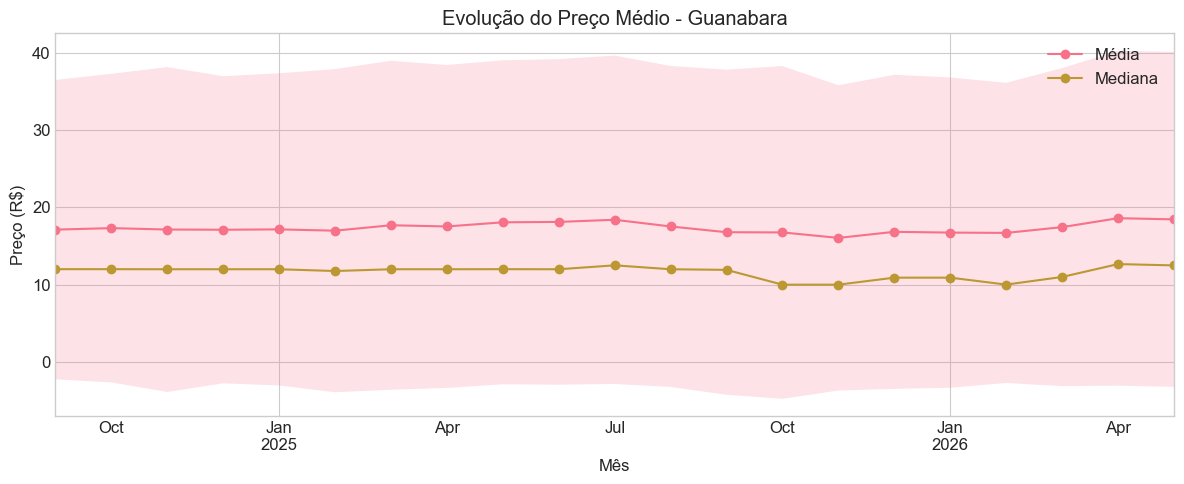

In [8]:
# Preço médio mensal - Guanabara
preco_mensal_guan = guanabara.groupby('mes')['preco'].agg(['mean', 'median', 'std'])
preco_mensal_guan.columns = ['Média', 'Mediana', 'Desvio Padrão']

fig, ax = plt.subplots(figsize=(12, 5))
preco_mensal_guan[['Média', 'Mediana']].plot(ax=ax, marker='o')
ax.fill_between(preco_mensal_guan.index, 
                preco_mensal_guan['Média'] - preco_mensal_guan['Desvio Padrão'],
                preco_mensal_guan['Média'] + preco_mensal_guan['Desvio Padrão'],
                alpha=0.2)
ax.set_title('Evolução do Preço Médio - Guanabara')
ax.set_xlabel('Mês')
ax.set_ylabel('Preço (R$)')
ax.legend()
plt.tight_layout()
plt.show()

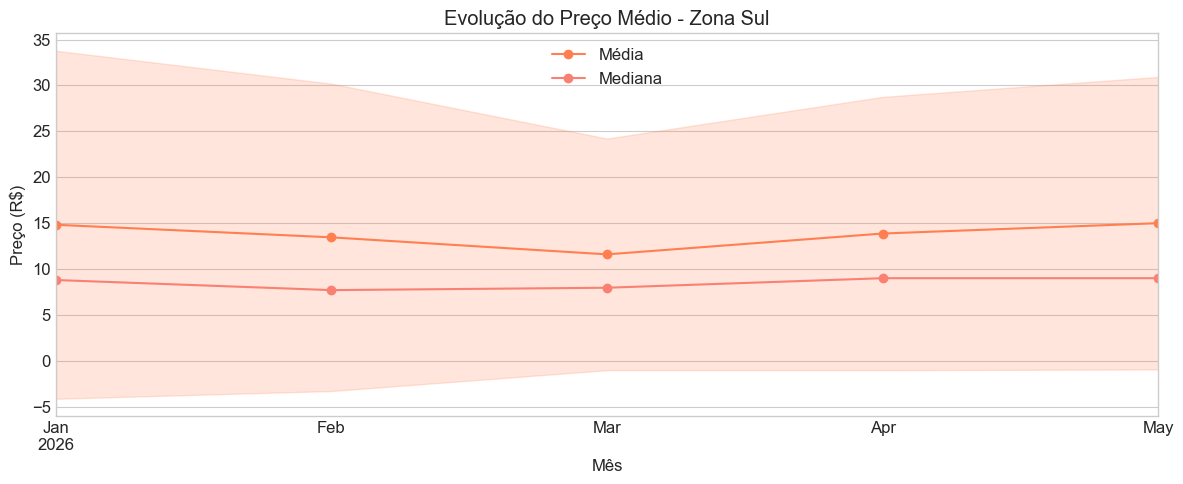

In [9]:
# Preço médio mensal - Zona Sul
preco_mensal_zsul = zsul.groupby('mes')['preco'].agg(['mean', 'median', 'std'])
preco_mensal_zsul.columns = ['Média', 'Mediana', 'Desvio Padrão']

fig, ax = plt.subplots(figsize=(12, 5))
preco_mensal_zsul[['Média', 'Mediana']].plot(ax=ax, marker='o', color=['coral', 'salmon'])
ax.fill_between(preco_mensal_zsul.index, 
                preco_mensal_zsul['Média'] - preco_mensal_zsul['Desvio Padrão'],
                preco_mensal_zsul['Média'] + preco_mensal_zsul['Desvio Padrão'],
                alpha=0.2, color='coral')
ax.set_title('Evolução do Preço Médio - Zona Sul')
ax.set_xlabel('Mês')
ax.set_ylabel('Preço (R$)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Produtos com Maior Variação de Preço

In [10]:
# Guanabara - produtos com maior variação
variacoes_guan = guanabara.groupby('produto')['preco'].agg(['mean', 'std', 'min', 'max'])
variacoes_guan['cv'] = (variacoes_guan['std'] / variacoes_guan['mean'] * 100).round(2)
variacoes_guan = variacoes_guan[variacoes_guan['mean'] > 5]  # filtrar produtos > R$5
variacoes_guan = variacoes_guan.sort_values('cv', ascending=False).head(15)

print('=== Guanabara - Maior Variação (%) ===')
variacoes_guan[['mean', 'min', 'max', 'cv']].style.format({
    'mean': 'R$ {:.2f}', 'min': 'R$ {:.2f}', 'max': 'R$ {:.2f}', 'cv': '{:.1f}%'
})

=== Guanabara - Maior Variação (%) ===


,mean,min,max,cv
produto,,,,
Chocolate Garoto (Exc. Talento ) 80g/90g,R$ 7.00,R$ 3.99,R$ 10.90,24.1%
Limpador Mr. MÃºsculo Refil Cozinha 400ml c/ 20% Desc,R$ 8.10,R$ 5.99,R$ 11.90,23.8%
Creme de Pentear Lola Meu Cacho Minha Vida 500g,R$ 37.22,R$ 29.98,R$ 50.89,23.0%
DESINFETANTE URCA 2L,R$ 5.44,R$ 3.99,R$ 11.90,22.0%
Chocolate Nestle 80g,R$ 7.50,R$ 4.49,R$ 9.60,21.6%
"LAVA ROU PO OMO LAVAGEM PERFEITA 2,2kg",R$ 28.30,R$ 20.60,R$ 34.90,21.5%
Shampoo Tresemme 400ml,R$ 17.26,R$ 13.98,R$ 27.20,21.5%
FeijÃ£o Preto Copa Kg,R$ 5.42,R$ 3.47,R$ 7.29,21.2%
Shampoo Clear 400ml,R$ 28.62,R$ 19.98,R$ 35.99,20.6%


In [11]:
# Zona Sul - produtos com maior variação
variacoes_zsul = zsul.groupby('produto')['preco'].agg(['mean', 'std', 'min', 'max'])
variacoes_zsul['cv'] = (variacoes_zsul['std'] / variacoes_zsul['mean'] * 100).round(2)
variacoes_zsul = variacoes_zsul[variacoes_zsul['mean'] > 5]
variacoes_zsul = variacoes_zsul.sort_values('cv', ascending=False).head(15)

print('=== Zona Sul - Maior Variação (%) ===')
variacoes_zsul[['mean', 'min', 'max', 'cv']].style.format({
    'mean': 'R$ {:.2f}', 'min': 'R$ {:.2f}', 'max': 'R$ {:.2f}', 'cv': '{:.1f}%'
})

=== Zona Sul - Maior Variação (%) ===


,mean,min,max,cv
produto,,,,
Farinha De Trigo Dona Benta 1kg,R$ 11.92,R$ 5.99,R$ 250.00,277.0%
CafÃ© Torrado e MoÃ­do Melitta A VÃ¡cuo 500g,R$ 33.93,R$ 27.90,R$ 250.00,70.5%
Abobrinha Italiana Cariorta 1Kg,R$ 9.84,R$ 6.99,R$ 16.99,24.4%
"MamÃ£o Papaia Cariorta 1,2kg",R$ 11.87,R$ 9.99,R$ 15.99,23.6%
MamÃ£o Papaia Unidade,R$ 6.69,R$ 3.87,R$ 9.09,21.5%
Morango 250g,R$ 11.90,R$ 8.99,R$ 15.09,20.5%
"MelÃ£o Amarelo Metade 1,3kg",R$ 8.69,R$ 4.85,R$ 9.99,19.2%
Leite Longa Vida Integral ElegÃª Tetra Pak 1L,R$ 6.54,R$ 4.38,R$ 7.69,18.0%
Creme de Leite NestlÃ© 10% GrÃ¡tis 200g,R$ 5.09,R$ 3.99,R$ 5.99,17.4%


## 6. Top 10 Produtos Mais Caros

C:\Users\lfkop\AppData\Local\Temp\ipykernel_17392\2721308475.py:13: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lfkop\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


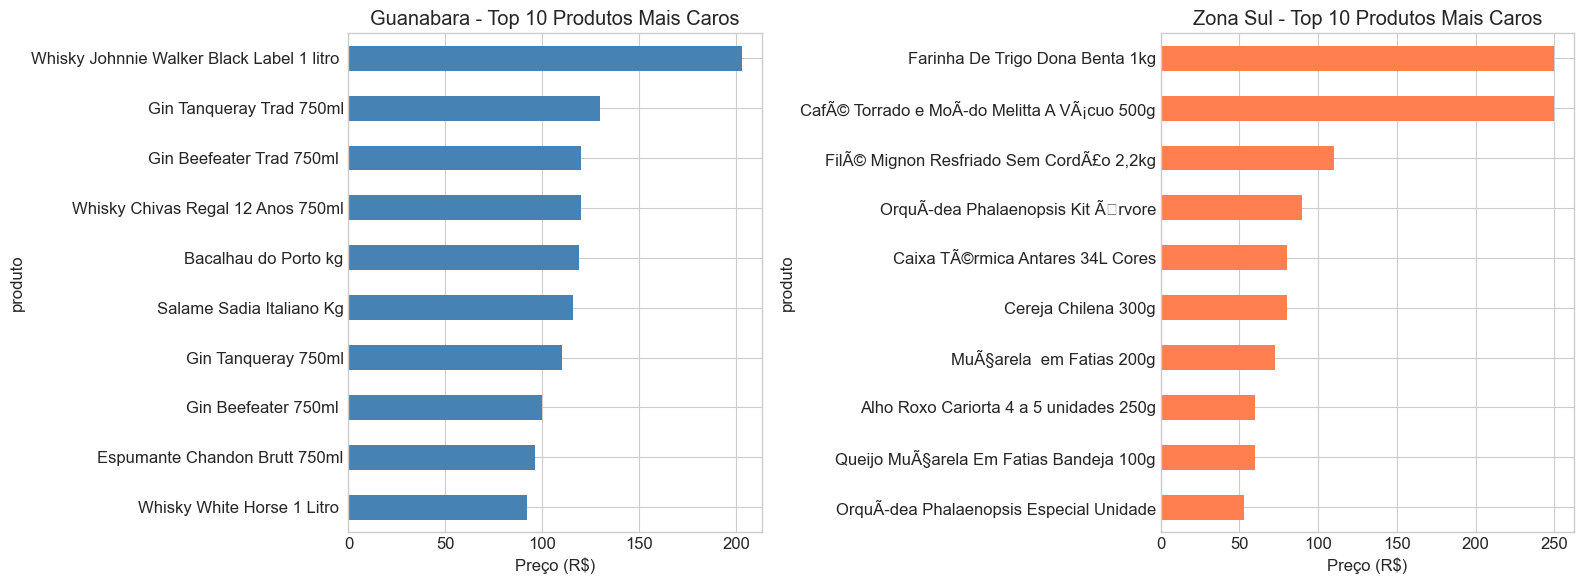

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_guan = guanabara.groupby('produto')['preco'].max().sort_values(ascending=True).tail(10)
top_guan.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Guanabara - Top 10 Produtos Mais Caros')
axes[0].set_xlabel('Preço (R$)')

top_zsul = zsul.groupby('produto')['preco'].max().sort_values(ascending=True).tail(10)
top_zsul.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Zona Sul - Top 10 Produtos Mais Caros')
axes[1].set_xlabel('Preço (R$)')

plt.tight_layout()
plt.show()

## 7. Top 10 Produtos Mais Baratos

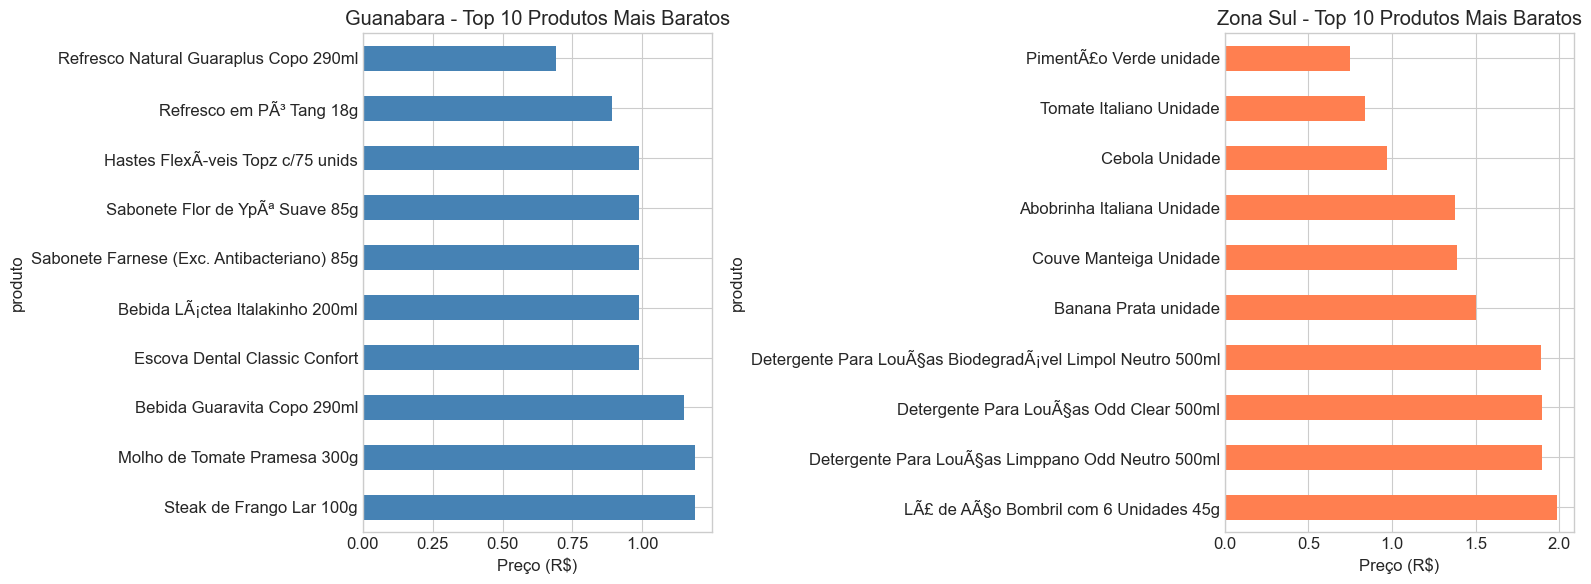

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bottom_guan = guanabara.groupby('produto')['preco'].min().sort_values(ascending=False).tail(10)
bottom_guan.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Guanabara - Top 10 Produtos Mais Baratos')
axes[0].set_xlabel('Preço (R$)')

bottom_zsul = zsul.groupby('produto')['preco'].min().sort_values(ascending=False).tail(10)
bottom_zsul.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Zona Sul - Top 10 Produtos Mais Baratos')
axes[1].set_xlabel('Preço (R$)')

plt.tight_layout()
plt.show()

## 8. Distribuição de Preços

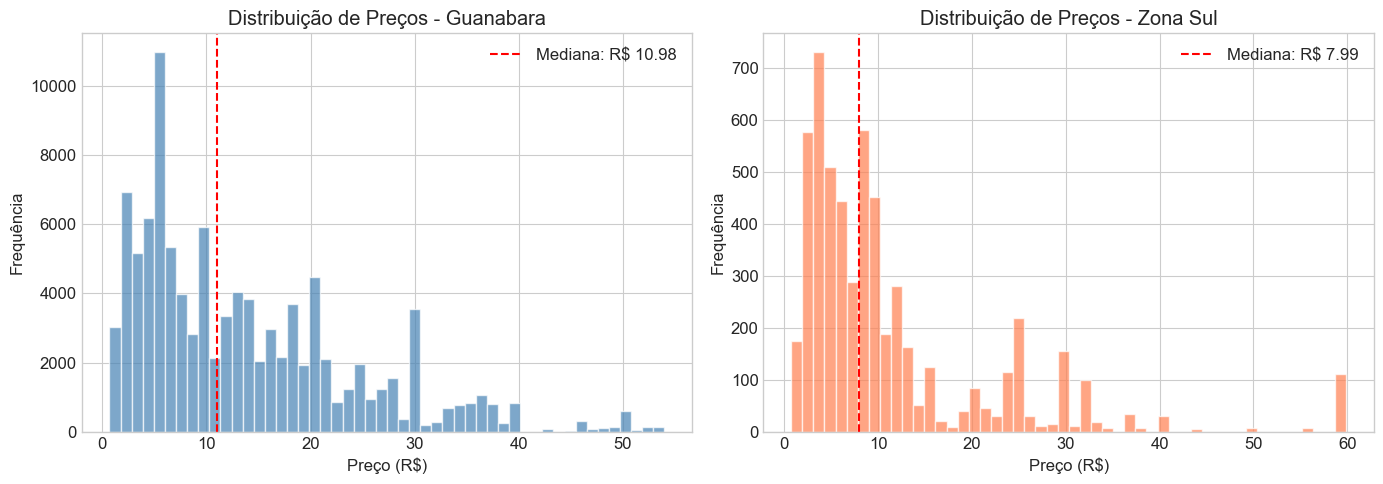

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filtrar preços extremos para melhor visualização
guanabara_filtrado = guanabara[guanabara['preco'] <= guanabara['preco'].quantile(0.95)]
zsul_filtrado = zsul[zsul['preco'] <= zsul['preco'].quantile(0.95)]

axes[0].hist(guanabara_filtrado['preco'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('Distribuição de Preços - Guanabara')
axes[0].set_xlabel('Preço (R$)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(guanabara_filtrado['preco'].median(), color='red', linestyle='--', label=f'Mediana: R$ {guanabara_filtrado["preco"].median():.2f}')
axes[0].legend()

axes[1].hist(zsul_filtrado['preco'], bins=50, color='coral', alpha=0.7, edgecolor='white')
axes[1].set_title('Distribuição de Preços - Zona Sul')
axes[1].set_xlabel('Preço (R$)')
axes[1].set_ylabel('Frequência')
axes[1].axvline(zsul_filtrado['preco'].median(), color='red', linestyle='--', label=f'Mediana: R$ {zsul_filtrado["preco"].median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Comparação de Produtos Comuns (Arroz, Feijão, Leite, etc.)

C:\Users\lfkop\AppData\Local\Temp\ipykernel_17392\2358382728.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend()
C:\Users\lfkop\AppData\Local\Temp\ipykernel_17392\2358382728.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend()


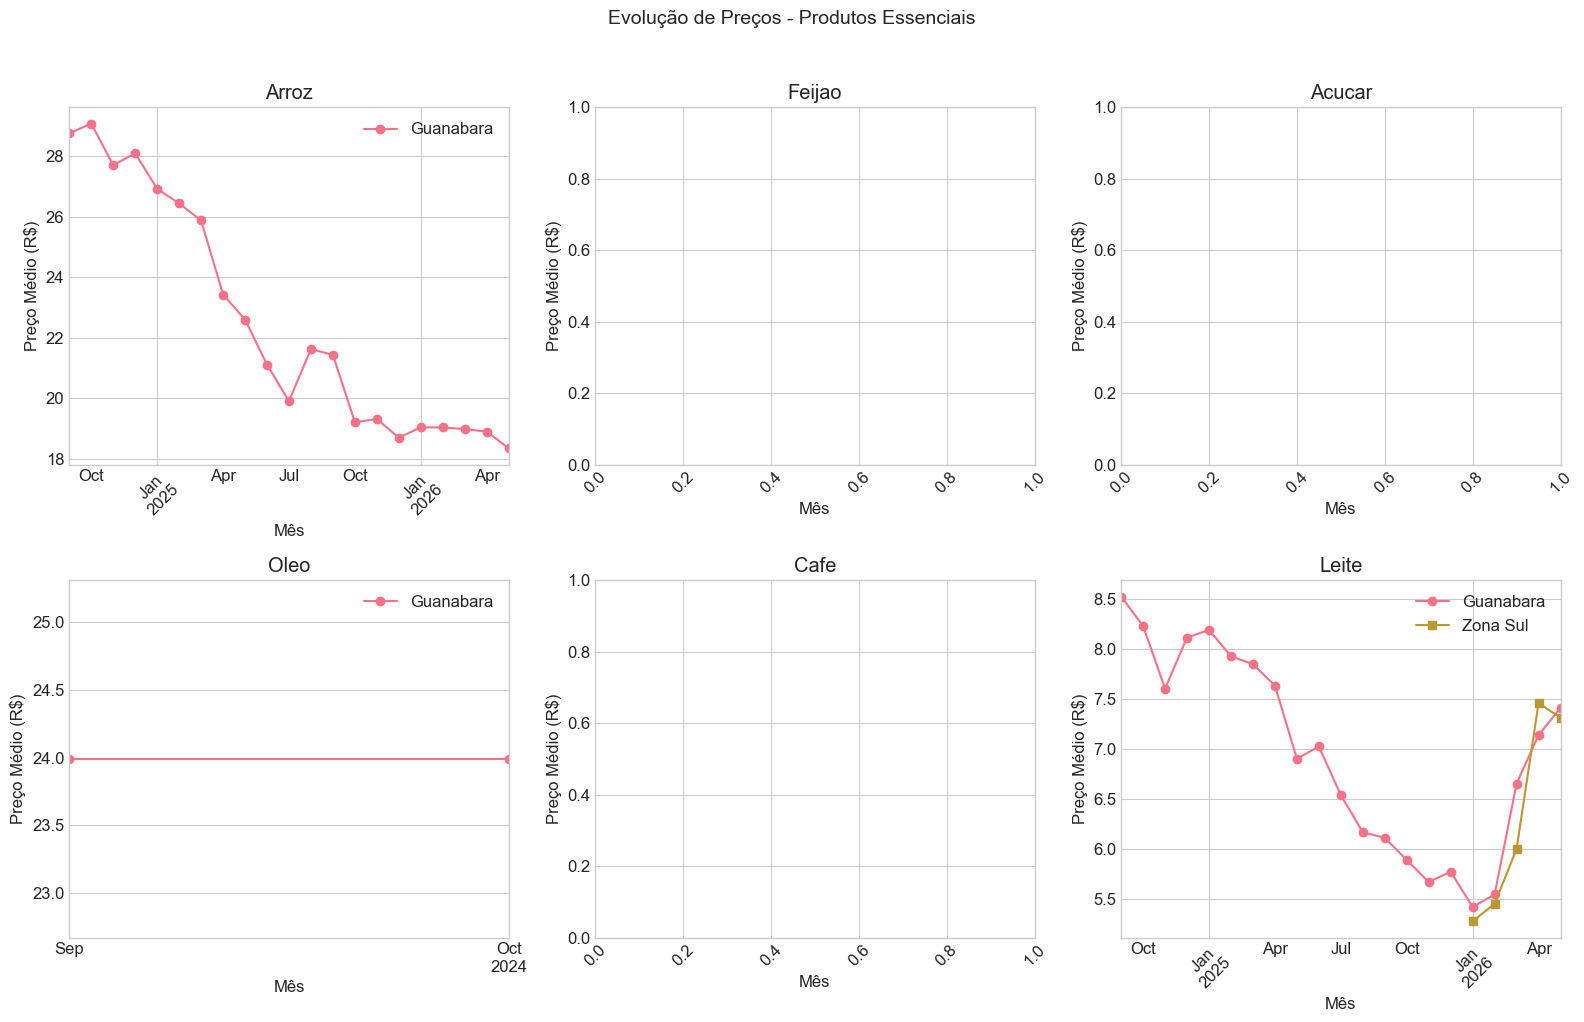

In [15]:
# Produtos essenciais para comparação
produtos_essenciais = [
    'arroz', 'feijao', 'acucar', 'oleo', 'cafe', 'leite'
]

def buscar_produto(df, termo):
    mask = df['produto'].str.lower().str.contains(termo.lower(), na=False)
    return df[mask]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, produto in enumerate(produtos_essenciais):
    dados_guan = buscar_produto(guanabara, produto)
    dados_zsul = buscar_produto(zsul, produto)
    
    if len(dados_guan) > 0:
        dados_guan.groupby('mes')['preco'].mean().plot(ax=axes[idx], label='Guanabara', marker='o')
    if len(dados_zsul) > 0:
        dados_zsul.groupby('mes')['preco'].mean().plot(ax=axes[idx], label='Zona Sul', marker='s')
    
    axes[idx].set_title(f'{produto.title()}')
    axes[idx].set_xlabel('Mês')
    axes[idx].set_ylabel('Preço Médio (R$)')
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Evolução de Preços - Produtos Essenciais', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Estatísticas Detalhadas por Produto

In [16]:
# Tabela comparativa de produtos essenciais
comparacao = []
for produto in produtos_essenciais:
    dados_guan = buscar_produto(guanabara, produto)
    dados_zsul = buscar_produto(zsul, produto)
    
    comparacao.append({
        'Produto': produto.title(),
        'Guanabara Média': dados_guan['preco'].mean() if len(dados_guan) > 0 else None,
        'Guanabara Mediana': dados_guan['preco'].median() if len(dados_guan) > 0 else None,
        'Zona Sul Média': dados_zsul['preco'].mean() if len(dados_zsul) > 0 else None,
        'Zona Sul Mediana': dados_zsul['preco'].median() if len(dados_zsul) > 0 else None,
    })

df_comparacao = pd.DataFrame(comparacao)
df_comparacao.style.format({
    'Guanabara Média': 'R$ {:.2f}',
    'Guanabara Mediana': 'R$ {:.2f}',
    'Zona Sul Média': 'R$ {:.2f}',
    'Zona Sul Mediana': 'R$ {:.2f}'
})

,Produto,Guanabara Média,Guanabara Mediana,Zona Sul Média,Zona Sul Mediana
0,Arroz,R$ 22.52,R$ 21.50,R$ nan,R$ nan
1,Feijao,R$ nan,R$ nan,R$ nan,R$ nan
2,Acucar,R$ nan,R$ nan,R$ nan,R$ nan
3,Oleo,R$ 23.99,R$ 23.99,R$ nan,R$ nan
4,Cafe,R$ nan,R$ nan,R$ nan,R$ nan
5,Leite,R$ 6.97,R$ 5.79,R$ 6.28,R$ 5.99


## 11. Análise de Sazonalidade

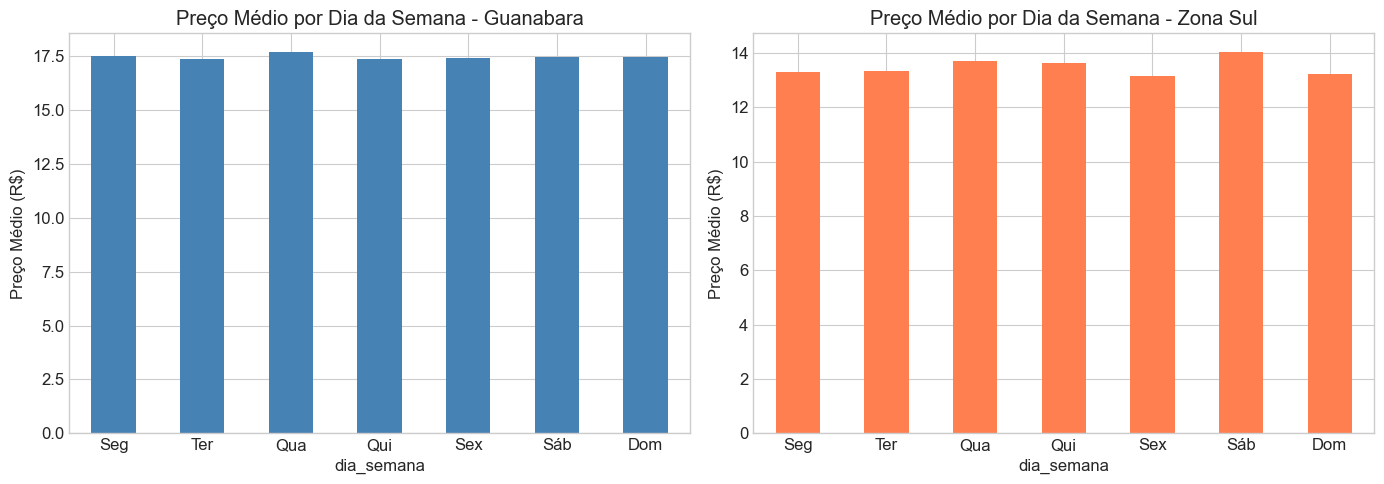

In [17]:
# Preço médio por dia da semana
guanabara['dia_semana'] = guanabara['data'].dt.day_name()
zsul['dia_semana'] = zsul['data'].dt.day_name()

dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_pt = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

preco_dia_guan = guanabara.groupby('dia_semana')['preco'].mean().reindex(dias_ordem)
preco_dia_guan.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_xticklabels(dias_pt, rotation=0)
axes[0].set_title('Preço Médio por Dia da Semana - Guanabara')
axes[0].set_ylabel('Preço Médio (R$)')

preco_dia_zsul = zsul.groupby('dia_semana')['preco'].mean().reindex(dias_ordem)
preco_dia_zsul.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xticklabels(dias_pt, rotation=0)
axes[1].set_title('Preço Médio por Dia da Semana - Zona Sul')
axes[1].set_ylabel('Preço Médio (R$)')

plt.tight_layout()
plt.show()

## 12. Exportar Dados Processados

In [18]:
# Salvar dados combinados para análises futuras
combinado = pd.concat([
    guanabara[['data', 'supermercado', 'setor', 'produto', 'preco']],
    zsul[['data', 'supermercado', 'produto', 'preco']]
], ignore_index=True)

combinado.to_csv('dados_completos.csv', index=False, encoding='utf-8')
print(f'Dados salvos: {len(combinado):,} registros em dados_completos.csv')
print(f'\nResumo final:')
print(f'  - Guanabara: {len(guanabara):,} registros, {guanabara["produto"].nunique():,} produtos únicos')
print(f'  - Zona Sul: {len(zsul):,} registros, {zsul["produto"].nunique():,} produtos únicos')

Dados salvos: 113,676 registros em dados_completos.csv

Resumo final:
  - Guanabara: 107,758 registros, 607 produtos únicos
  - Zona Sul: 5,918 registros, 174 produtos únicos
